In [13]:
# 1. Merge clean Orders with Customers (the key is 'customer_id')
full_df = pd.merge(clean_orders, customers, on='customer_id', how='inner')

# 2. Merge that result with purchased Items (the key is 'order_id')
full_df = pd.merge(full_df, items, on='order_id', how='inner')

# Check the result
print("Merge completed! All tables are united in 'full_df'.")
print("Super-dataset size:", full_df.shape)

Merge completed! All tables are united in 'full_df'.
Super-dataset size: (110197, 18)


In [14]:
# 1. Group by State ('customer_state') and sum the Price ('price')
sales_by_state = full_df.groupby('customer_state')['price'].sum().reset_index()

# 2. Sort the results from highest to lowest to see the winners
top_5_states = sales_by_state.sort_values(by='price', ascending=False).head(5)

# 3. Format the numbers to look nice and like currency
pd.options.display.float_format = '{:,.2f} €'.format

print("--- TOP 5 REVENUE GENERATING STATES ---")
print(top_5_states)

--- TOP 5 REVENUE GENERATING STATES ---
   customer_state          price
25             SP 5,067,633.16 €
18             RJ 1,759,651.13 €
10             MG 1,552,481.83 €
22             RS   728,897.47 €
17             PR   666,063.51 €


/var/folders/gn/9myyg2zs2xq09kglt98348fr0000gn/T/ipykernel_3371/3970820560.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_states, x='customer_state', y='price', palette='viridis')


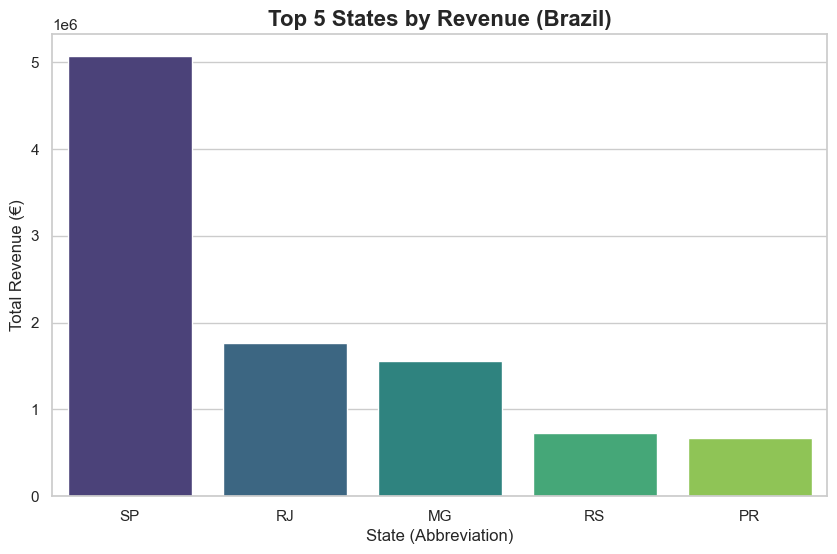

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configure an elegant and professional style for the chart
sns.set_theme(style="whitegrid")

# 2. Prepare the "canvas" (image size)
plt.figure(figsize=(10, 6))

# 3. Draw a bar chart
sns.barplot(data=top_5_states, x='customer_state', y='price', palette='viridis')

# 4. Add title and axis labels to make it understandable
plt.title('Top 5 States by Revenue (Brazil)', fontsize=16, weight='bold')
plt.xlabel('State (Abbreviation)', fontsize=12)
plt.ylabel('Total Revenue (€)', fontsize=12)

# 5. Show the masterpiece!
plt.show()


In [16]:
# Save our clean and merged dataset to a new CSV file
full_df.to_csv("olist_clean_merged_data.csv", index=False)

print("Project saved successfully! You are now a data analyst.")

Project saved successfully! You are now a data analyst.


In [6]:
# 1. Transform dates from "Text" to "Datetime" format (Datetime)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# 2. Filter: Keep ONLY orders that were delivered (remove canceled) 
clean_orders = orders[orders['order_status'] == 'delivered']

# Check how the cleaning turned out
print("Cleaning completed!")
print(f"We went from {orders.shape[0]} raw orders to {clean_orders.shape[0]} actual delivered orders.")

Cleaning completed!
We went from 99441 raw orders to 96478 actual delivered orders.


In [17]:
# Vamos a ver cuántas filas y columnas tiene
print("Orders table size:", orders.shape)

# Vamos a ver qué tipo de datos contiene y si faltan cosas
print("\n--- ORDERS X-RAY (INFO) ---")
orders.info()

Orders table size: (99441, 8)

--- ORDERS X-RAY (INFO) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
# 1. Cargamos los archivos y los guardamos con nombres fáciles
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")

print("2. Raw data loaded into memory...")

2. Raw data loaded into memory...


In [9]:
import pandas as pd
print("1. Tools loaded...")

1. Tools loaded...
